# VERİ

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.optimize import least_squares

plt.rcParams.update({
    "figure.facecolor": "#0B0F14",
    "axes.facecolor": "#0B0F14",
    "savefig.facecolor": "#0B0F14",
    "axes.edgecolor": "#243040",
    "axes.labelcolor": "#C9D6E2",
    "axes.titlecolor": "#E6EDF3",
    "text.color": "#C9D6E2",
    "xtick.color": "#7D8FA3",
    "ytick.color": "#7D8FA3",
    "grid.color": "#161D26",
    "legend.facecolor": "#0B0F14",
    "legend.edgecolor": "#243040",
    "font.family": "monospace",
    "axes.grid": True,
    "figure.dpi": 120,
})

paleta = ["#22D3EE", "#F59E0B", "#A78BFA", "#34D399", "#F87171"]
harita = LinearSegmentedColormap.from_list("iskele", ["#0E1B24", "#22D3EE", "#F59E0B"])
uretec = np.random.default_rng(20260810)
ornek_sayisi = 1000

In [2]:
sonuclar = {}
araliklar = {}
alanlar = {}


def dogrusal_uydur(tasarim, hedef):
    katsayi, *_ = np.linalg.lstsq(tasarim, hedef, rcond=None)
    return katsayi


def paket_ac(p, sekiller):
    parcalar, k = [], 0
    for s in sekiller:
        boyut = int(np.prod(s))
        parcalar.append(np.asarray(p[k:k + boyut]).reshape(s))
        k += boyut
    return parcalar


def us_cekirdek(t, beta):
    fark = t[:, None] - t[None, :]
    return np.exp(-abs(beta) * np.clip(fark, 0.0, None)) * np.tril(np.ones((len(t), len(t))), -1)


def gurultu(artik, parametre):
    a = np.asarray(artik, float).reshape(len(artik), -1)
    payda = max(len(a) - parametre, 1)
    return a.T @ a / payda + 1e-10 * np.eye(a.shape[1])


def orneklem(ortalama, kovaryans, sayi):
    L = np.linalg.cholesky(np.atleast_2d(kovaryans))
    return ortalama[None] + uretec.standard_normal((sayi, *ortalama.shape)) @ L.T


def crps(ornek, gercek):
    m = ornek.shape[0]
    sirali = np.sort(ornek, axis=0)
    indis = np.arange(1, m + 1).reshape(-1, 1, 1)
    ikinci = np.sum((2 * indis - m - 1) * sirali, axis=0) / (m * m)
    birinci = np.abs(ornek - gercek[None]).mean(axis=0)
    return float((birinci - ikinci).mean())


def euler_maruyama(alan, kovaryans, baslangic, zamanlar, adim, sayi):
    L = np.linalg.cholesky(np.atleast_2d(kovaryans))
    boyut = L.shape[0]
    yol = np.zeros((sayi, len(zamanlar) + 1, boyut))
    yol[:, 0] = baslangic
    for i, zaman in enumerate(zamanlar):
        yol[:, i + 1] = yol[:, i] + alan(zaman, yol[:, i]) * adim + uretec.standard_normal((sayi, boyut)) @ L.T
    return yol


def kaydet(kod, tur, sinif, gercek, ortalama, kovaryans):
    g = np.asarray(gercek, float).reshape(len(gercek), -1)
    mu = np.asarray(ortalama, float).reshape(g.shape)
    S = np.atleast_2d(kovaryans)
    boyut = g.shape[1]
    L = np.linalg.cholesky(S)
    z = np.linalg.solve(L, (g - mu).T).T
    nll = 0.5 * (boyut * np.log(2 * np.pi) + 2 * np.sum(np.log(np.diag(L))) + np.sum(z ** 2, axis=1)).mean() / boyut
    ornek = orneklem(mu, S, ornek_sayisi)
    alt, orta, ust = np.quantile(ornek, [0.05, 0.5, 0.95], axis=0)
    sonuclar[kod] = {
        "Tur": tur,
        "Sinif": sinif,
        "RMSE": float(np.sqrt(np.mean((g - mu) ** 2))),
        "CRPS": crps(ornek, g),
        "NLL": float(nll),
        "KAPSAM": float(np.mean((g >= alt) & (g <= ust))),
    }
    araliklar[kod] = (alt, orta, ust)
    print(kod, tur, "|", sinif, "|", {k: round(v, 4) for k, v in sonuclar[kod].items() if k not in ("Tur", "Sinif")})

In [3]:
ham = pd.read_csv("autism.csv")

seri = pd.DataFrame({
    "kazanim": 100 * np.log(ham["kazanim"]),
    "genelleme": 100 * np.log(ham["genelleme"]),
    "edinim": 100 * np.log(ham["edinim"]),
    "deneme": 100 * np.log(ham["deneme"]),
    "ipucu": ham["ipucu"],
    "problem": ham["problem"],
})

seri.describe().T

,count,mean,std,min,25%,50%,75%,max
kazanim,204.0,463.258652,71.236364,346.573590,407.136983,461.660374,527.511809,578.695873
genelleme,204.0,392.437017,67.575640,289.037176,332.520764,393.241339,454.262433,499.687438
edinim,204.0,581.736060,53.291961,492.391478,538.168144,568.173457,632.173255,676.937788
deneme,204.0,610.744459,43.784707,537.717476,570.603824,606.710225,647.391722,683.184568
ipucu,204.0,1.675294,0.801984,0.440000,1.030000,1.555000,2.240000,3.630000
problem,204.0,2.967402,1.209023,1.200000,1.885000,3.010000,3.882500,9.400000


In [4]:
n = len(seri)
kesim = int(n * 0.8)
adim = 0.25
t = np.arange(n) * adim
tn = t / t.max()
egitim = slice(0, kesim)
test = slice(kesim, n)

olcekli = (seri - seri.iloc[egitim].mean()) / seri.iloc[egitim].std()

giris_skaler = olcekli["deneme"].to_numpy()
cikis_skaler = olcekli["genelleme"].to_numpy()
giris_vektor = olcekli[["deneme", "ipucu", "problem"]].to_numpy()
cikis_vektor = olcekli[["kazanim", "genelleme", "edinim"]].to_numpy()
durum_skaler = olcekli["kazanim"].to_numpy()
durum_vektor = olcekli[["kazanim", "genelleme", "edinim"]].to_numpy()

temel_skaler = np.column_stack([np.ones(n), tn])
temel_vektor = np.column_stack([np.ones(n), tn])

n, kesim, giris_vektor.shape, durum_vektor.shape

(204, 163, (204, 3), (204, 3))

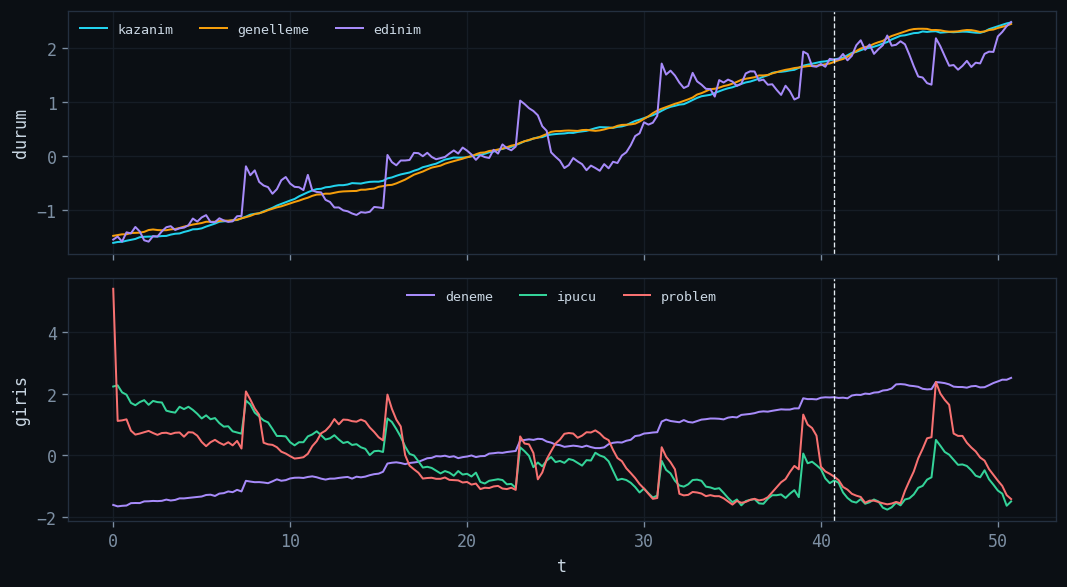

In [5]:
sekil, eksen = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
for i, ad in enumerate(["kazanim", "genelleme", "edinim"]):
    eksen[0].plot(t, olcekli[ad], color=paleta[i], lw=1.2, label=ad)
for i, ad in enumerate(["deneme", "ipucu", "problem"]):
    eksen[1].plot(t, olcekli[ad], color=paleta[i + 2], lw=1.2, label=ad)
for e in eksen:
    e.axvline(t[kesim], color="#E6EDF3", ls="--", lw=0.8)
    e.legend(ncol=3, fontsize=8, frameon=False)
eksen[0].set_ylabel("durum")
eksen[1].set_ylabel("giris")
eksen[1].set_xlabel("t")
plt.tight_layout()
plt.show()

# MODEL

## Cebirsel · Skaler · Doğrusal

In [6]:
tasarim = np.column_stack([giris_skaler[egitim], np.ones(kesim)])
katsayi = dogrusal_uydur(tasarim, cikis_skaler[egitim])
S = gurultu(cikis_skaler[egitim] - tasarim @ katsayi, tasarim.shape[1])
ortalama = katsayi[0] * giris_skaler[test] + katsayi[1]

kaydet("M01", "Cebirsel", "Skaler Dogrusal", cikis_skaler[test], ortalama, S)

M01 Cebirsel | Skaler Dogrusal | {'RMSE': 0.0992, 'CRPS': 0.0571, 'NLL': -0.8329, 'KAPSAM': 0.9268}


## Cebirsel · Skaler · Doğrusal Olmayan

In [7]:
def cebirsel_skaler(u, p):
    return p[0] * np.tanh(p[1] * u + p[2]) + p[3]


cozum = least_squares(
    lambda p: cebirsel_skaler(giris_skaler[egitim], p) - cikis_skaler[egitim],
    [1.0, 1.0, 0.0, 0.0],
)
S = gurultu(cozum.fun, cozum.x.size)
ortalama = cebirsel_skaler(giris_skaler[test], cozum.x)

kaydet("M02", "Cebirsel", "Skaler Dogrusal Olmayan", cikis_skaler[test], ortalama, S)

M02 Cebirsel | Skaler Dogrusal Olmayan | {'RMSE': 0.3317, 'CRPS': 0.2516, 'NLL': 2.8798, 'KAPSAM': 0.1707}


## Cebirsel · Vektörel · Doğrusal

In [8]:
tasarim = np.column_stack([giris_vektor[egitim], np.ones(kesim)])
katsayi = dogrusal_uydur(tasarim, cikis_vektor[egitim])
A, B = katsayi[:-1].T, katsayi[-1]
S = gurultu(cikis_vektor[egitim] - tasarim @ katsayi, tasarim.shape[1])
ortalama = giris_vektor[test] @ A.T + B

kaydet("M03", "Cebirsel", "Vektorel Dogrusal", cikis_vektor[test], ortalama, S)

M03 Cebirsel | Vektorel Dogrusal | {'RMSE': 0.2915, 'CRPS': 0.1652, 'NLL': -0.4743, 'KAPSAM': 0.5935}


## Cebirsel · Vektörel · Doğrusal Olmayan

In [9]:
sekiller = [(3, 3), (3,), (3, 3), (3,)]


def cebirsel_vektorel(U, p):
    W, c, A, B = paket_ac(p, sekiller)
    return np.tanh(U @ W.T + c) @ A.T + B


baslangic = np.concatenate([np.eye(3).ravel() * 0.5, np.zeros(3), np.eye(3).ravel() * 0.5, np.zeros(3)])
cozum = least_squares(
    lambda p: (cebirsel_vektorel(giris_vektor[egitim], p) - cikis_vektor[egitim]).ravel(),
    baslangic,
)
S = gurultu(cebirsel_vektorel(giris_vektor[egitim], cozum.x) - cikis_vektor[egitim], cozum.x.size // 3)
ortalama = cebirsel_vektorel(giris_vektor[test], cozum.x)

kaydet("M04", "Cebirsel", "Vektorel Dogrusal Olmayan", cikis_vektor[test], ortalama, S)

M04 Cebirsel | Vektorel Dogrusal Olmayan | {'RMSE': 0.2916, 'CRPS': 0.1924, 'NLL': 1.7476, 'KAPSAM': 0.4146}


## Fark · Skaler · Doğrusal

In [10]:
tasarim = np.column_stack([durum_skaler[:kesim - 1], np.ones(kesim - 1)])
katsayi = dogrusal_uydur(tasarim, durum_skaler[1:kesim])
S = gurultu(durum_skaler[1:kesim] - tasarim @ katsayi, tasarim.shape[1])
ortalama = katsayi[0] * durum_skaler[kesim - 1:n - 1] + katsayi[1]

kaydet("M05", "Fark", "Skaler Dogrusal", durum_skaler[test], ortalama, S)

M05 Fark | Skaler Dogrusal | {'RMSE': 0.0182, 'CRPS': 0.0105, 'NLL': -2.4096, 'KAPSAM': 0.7805}


## Fark · Skaler · Doğrusal Olmayan

In [11]:
def fark_skaler(x, p):
    return p[0] * np.tanh(p[1] * x + p[2]) + p[3]


cozum = least_squares(
    lambda p: fark_skaler(durum_skaler[:kesim - 1], p) - durum_skaler[1:kesim],
    [1.0, 1.0, 0.0, 0.0],
)
S = gurultu(cozum.fun, cozum.x.size)
ortalama = fark_skaler(durum_skaler[kesim - 1:n - 1], cozum.x)

kaydet("M06", "Fark", "Skaler Dogrusal Olmayan", durum_skaler[test], ortalama, S)

M06 Fark | Skaler Dogrusal Olmayan | {'RMSE': 0.0175, 'CRPS': 0.01, 'NLL': -2.5028, 'KAPSAM': 0.7561}


## Fark · Vektörel · Doğrusal

In [12]:
tasarim = np.column_stack([durum_vektor[:kesim - 1], np.ones(kesim - 1)])
katsayi = dogrusal_uydur(tasarim, durum_vektor[1:kesim])
A, B = katsayi[:-1].T, katsayi[-1]
S = gurultu(durum_vektor[1:kesim] - tasarim @ katsayi, tasarim.shape[1])
ortalama = durum_vektor[kesim - 1:n - 1] @ A.T + B

kaydet("M07", "Fark", "Vektorel Dogrusal", durum_vektor[test], ortalama, S)

M07 Fark | Vektorel Dogrusal | {'RMSE': 0.1057, 'CRPS': 0.0386, 'NLL': -1.8551, 'KAPSAM': 0.8455}


## Fark · Vektörel · Doğrusal Olmayan

In [13]:
def fark_vektorel(X, p):
    W, c, A, B = paket_ac(p, sekiller)
    return np.tanh(X @ W.T + c) @ A.T + B


cozum = least_squares(
    lambda p: (fark_vektorel(durum_vektor[:kesim - 1], p) - durum_vektor[1:kesim]).ravel(),
    baslangic,
)
S = gurultu(fark_vektorel(durum_vektor[:kesim - 1], cozum.x) - durum_vektor[1:kesim], cozum.x.size // 3)
ortalama = fark_vektorel(durum_vektor[kesim - 1:n - 1], cozum.x)

kaydet("M08", "Fark", "Vektorel Dogrusal Olmayan", durum_vektor[test], ortalama, S)

M08 Fark | Vektorel Dogrusal Olmayan | {'RMSE': 0.1281, 'CRPS': 0.0626, 'NLL': 2.7282, 'KAPSAM': 0.374}


## Diferansiyel · Skaler · Doğrusal

In [14]:
artim = (durum_skaler[1:kesim] - durum_skaler[:kesim - 1]) / adim
tasarim = np.column_stack([durum_skaler[:kesim - 1], np.ones(kesim - 1)])
katsayi = dogrusal_uydur(tasarim, artim)
alan = lambda zaman, durum, p=katsayi: p[0] * durum + p[1]

S = gurultu(durum_skaler[1:kesim] - durum_skaler[:kesim - 1] - alan(t[:kesim - 1], durum_skaler[:kesim - 1]) * adim,
            tasarim.shape[1])
ortalama = durum_skaler[kesim - 1:n - 1] + alan(t[kesim - 1:n - 1], durum_skaler[kesim - 1:n - 1]) * adim
alanlar["M09"] = (alan, S)

kaydet("M09", "Diferansiyel", "Skaler Dogrusal", durum_skaler[test], ortalama, S)

M09 Diferansiyel | Skaler Dogrusal | {'RMSE': 0.0182, 'CRPS': 0.0105, 'NLL': -2.4096, 'KAPSAM': 0.7561}


## Diferansiyel · Skaler · Doğrusal Olmayan

In [15]:
def alan_skaler(zaman, durum, p):
    return p[0] * durum + p[1] * durum ** 2 + p[2] * np.sin(p[3] * zaman + p[4]) + p[5]


artim = (durum_skaler[1:kesim] - durum_skaler[:kesim - 1]) / adim
cozum = least_squares(
    lambda p: alan_skaler(t[:kesim - 1], durum_skaler[:kesim - 1], p) - artim,
    [-1.0, 0.0, 0.1, 1.0, 0.0, 0.0],
)
alan = lambda zaman, durum, p=cozum.x: alan_skaler(zaman, durum, p)

S = gurultu(durum_skaler[1:kesim] - durum_skaler[:kesim - 1] - alan(t[:kesim - 1], durum_skaler[:kesim - 1]) * adim,
            cozum.x.size)
ortalama = durum_skaler[kesim - 1:n - 1] + alan(t[kesim - 1:n - 1], durum_skaler[kesim - 1:n - 1]) * adim
alanlar["M10"] = (alan, S)

kaydet("M10", "Diferansiyel", "Skaler Dogrusal Olmayan", durum_skaler[test], ortalama, S)

M10 Diferansiyel | Skaler Dogrusal Olmayan | {'RMSE': 0.0184, 'CRPS': 0.0106, 'NLL': -2.3207, 'KAPSAM': 0.7317}


## Diferansiyel · Vektörel · Doğrusal

In [16]:
artim = (durum_vektor[1:kesim] - durum_vektor[:kesim - 1]) / adim
tasarim = np.column_stack([durum_vektor[:kesim - 1], np.ones(kesim - 1)])
katsayi = dogrusal_uydur(tasarim, artim)
A, B = katsayi[:-1].T, katsayi[-1]
alan = lambda zaman, durum, A=A, B=B: durum @ A.T + B

S = gurultu(durum_vektor[1:kesim] - durum_vektor[:kesim - 1] - alan(t[:kesim - 1], durum_vektor[:kesim - 1]) * adim,
            tasarim.shape[1])
ortalama = durum_vektor[kesim - 1:n - 1] + alan(t[kesim - 1:n - 1], durum_vektor[kesim - 1:n - 1]) * adim
alanlar["M11"] = (alan, S)

kaydet("M11", "Diferansiyel", "Vektorel Dogrusal", durum_vektor[test], ortalama, S)

M11 Diferansiyel | Vektorel Dogrusal | {'RMSE': 0.1057, 'CRPS': 0.0383, 'NLL': -1.8551, 'KAPSAM': 0.8293}


## Diferansiyel · Vektörel · Doğrusal Olmayan

In [17]:
sekiller_alan = [(3, 3), (3,), (3,), (3, 3), (3,)]


def alan_vektorel(zaman, durum, p):
    W, c, w, A, B = paket_ac(p, sekiller_alan)
    durum = np.atleast_2d(durum)
    return np.tanh(durum @ W.T + c + np.reshape(zaman, (-1, 1)) * w) @ A.T + B


artim = (durum_vektor[1:kesim] - durum_vektor[:kesim - 1]) / adim
baslangic_alan = np.concatenate([np.eye(3).ravel() * 0.5, np.zeros(3), np.zeros(3), np.zeros(9), np.zeros(3)])
cozum = least_squares(
    lambda p: (alan_vektorel(t[:kesim - 1], durum_vektor[:kesim - 1], p) - artim).ravel(),
    baslangic_alan,
)
alan = lambda zaman, durum, p=cozum.x: alan_vektorel(zaman, durum, p)

S = gurultu(durum_vektor[1:kesim] - durum_vektor[:kesim - 1] - alan(t[:kesim - 1], durum_vektor[:kesim - 1]) * adim,
            cozum.x.size // 3)
ortalama = durum_vektor[kesim - 1:n - 1] + alan(t[kesim - 1:n - 1], durum_vektor[kesim - 1:n - 1]) * adim
alanlar["M12"] = (alan, S)

kaydet("M12", "Diferansiyel", "Vektorel Dogrusal Olmayan", durum_vektor[test], ortalama, S)

M12 Diferansiyel | Vektorel Dogrusal Olmayan | {'RMSE': 1.0784, 'CRPS': 0.2588, 'NLL': 21.7136, 'KAPSAM': 0.6748}


## İntegral · Skaler · Doğrusal

In [18]:
def integral_skaler(p, dilim):
    K = us_cekirdek(t, p[1])
    return temel_skaler[dilim] @ p[2:] + adim * p[0] * (K[dilim] @ durum_skaler)


cozum = least_squares(
    lambda p: integral_skaler(p, egitim) - durum_skaler[egitim],
    [0.1, 1.0, 0.0, 0.0],
)
S = gurultu(cozum.fun, cozum.x.size)
ortalama = integral_skaler(cozum.x, test)

kaydet("M13", "Integral", "Skaler Dogrusal", durum_skaler[test], ortalama, S)

M13 Integral | Skaler Dogrusal | {'RMSE': 0.087, 'CRPS': 0.056, 'NLL': -0.7297, 'KAPSAM': 0.6341}


## İntegral · Skaler · Doğrusal Olmayan

In [19]:
def integral_skaler_dogrusalsiz(p, dilim):
    K = us_cekirdek(t, p[1])
    donusum = np.tanh(p[2] * durum_skaler + p[3])
    return temel_skaler[dilim] @ p[4:] + adim * p[0] * (K[dilim] @ donusum)


cozum = least_squares(
    lambda p: integral_skaler_dogrusalsiz(p, egitim) - durum_skaler[egitim],
    [0.1, 1.0, 1.0, 0.0, 0.0, 0.0],
)
S = gurultu(cozum.fun, cozum.x.size)
ortalama = integral_skaler_dogrusalsiz(cozum.x, test)

kaydet("M14", "Integral", "Skaler Dogrusal Olmayan", durum_skaler[test], ortalama, S)

M14 Integral | Skaler Dogrusal Olmayan | {'RMSE': 0.0189, 'CRPS': 0.0113, 'NLL': -2.4462, 'KAPSAM': 0.7805}


## İntegral · Vektörel · Doğrusal

In [20]:
sekiller_integral = [(1,), (3, 3), (2, 3)]


def integral_vektorel(p, dilim):
    beta, A, C = paket_ac(p, sekiller_integral)
    K = us_cekirdek(t, beta[0])
    return temel_vektor[dilim] @ C + adim * (K[dilim] @ durum_vektor) @ A.T


cozum = least_squares(
    lambda p: (integral_vektorel(p, egitim) - durum_vektor[egitim]).ravel(),
    np.concatenate([[1.0], (np.eye(3) * 0.1).ravel(), np.zeros(6)]),
)
S = gurultu(integral_vektorel(cozum.x, egitim) - durum_vektor[egitim], cozum.x.size // 3)
ortalama = integral_vektorel(cozum.x, test)

kaydet("M15", "Integral", "Vektorel Dogrusal", durum_vektor[test], ortalama, S)

M15 Integral | Vektorel Dogrusal | {'RMSE': 0.1287, 'CRPS': 0.0696, 'NLL': -1.158, 'KAPSAM': 0.6341}


## İntegral · Vektörel · Doğrusal Olmayan

In [21]:
sekiller_integral_dogrusalsiz = [(1,), (3, 3), (3,), (3, 3), (2, 3)]


def integral_vektorel_dogrusalsiz(p, dilim):
    beta, W, c, A, C = paket_ac(p, sekiller_integral_dogrusalsiz)
    K = us_cekirdek(t, beta[0])
    donusum = np.tanh(durum_vektor @ W.T + c)
    return temel_vektor[dilim] @ C + adim * (K[dilim] @ donusum) @ A.T


cozum = least_squares(
    lambda p: (integral_vektorel_dogrusalsiz(p, egitim) - durum_vektor[egitim]).ravel(),
    np.concatenate([[1.0], np.eye(3).ravel(), np.zeros(3), (np.eye(3) * 0.1).ravel(), np.zeros(6)]),
)
S = gurultu(integral_vektorel_dogrusalsiz(cozum.x, egitim) - durum_vektor[egitim], cozum.x.size // 3)
ortalama = integral_vektorel_dogrusalsiz(cozum.x, test)

kaydet("M16", "Integral", "Vektorel Dogrusal Olmayan", durum_vektor[test], ortalama, S)

M16 Integral | Vektorel Dogrusal Olmayan | {'RMSE': 0.2026, 'CRPS': 0.089, 'NLL': 0.4342, 'KAPSAM': 0.6016}


# DEĞERLENDİRME

In [22]:
turler = ["Cebirsel", "Fark", "Diferansiyel", "Integral"]
siniflar = ["Skaler Dogrusal", "Skaler Dogrusal Olmayan", "Vektorel Dogrusal", "Vektorel Dogrusal Olmayan"]

tablo = pd.DataFrame(sonuclar).T
tablo[["RMSE", "CRPS", "NLL", "KAPSAM"]] = tablo[["RMSE", "CRPS", "NLL", "KAPSAM"]].astype(float).round(4)
tablo

,Tur,Sinif,RMSE,CRPS,NLL,KAPSAM
M01,Cebirsel,Skaler Dogrusal,0.0992,0.0571,-0.8329,0.9268
M02,Cebirsel,Skaler Dogrusal Olmayan,0.3317,0.2516,2.8798,0.1707
M03,Cebirsel,Vektorel Dogrusal,0.2915,0.1652,-0.4743,0.5935
M04,Cebirsel,Vektorel Dogrusal Olmayan,0.2916,0.1924,1.7476,0.4146
M05,Fark,Skaler Dogrusal,0.0182,0.0105,-2.4096,0.7805
M06,Fark,Skaler Dogrusal Olmayan,0.0175,0.0100,-2.5028,0.7561
M07,Fark,Vektorel Dogrusal,0.1057,0.0386,-1.8551,0.8455
M08,Fark,Vektorel Dogrusal Olmayan,0.1281,0.0626,2.7282,0.3740
M09,Diferansiyel,Skaler Dogrusal,0.0182,0.0105,-2.4096,0.7561
M10,Diferansiyel,Skaler Dogrusal Olmayan,0.0184,0.0106,-2.3207,0.7317


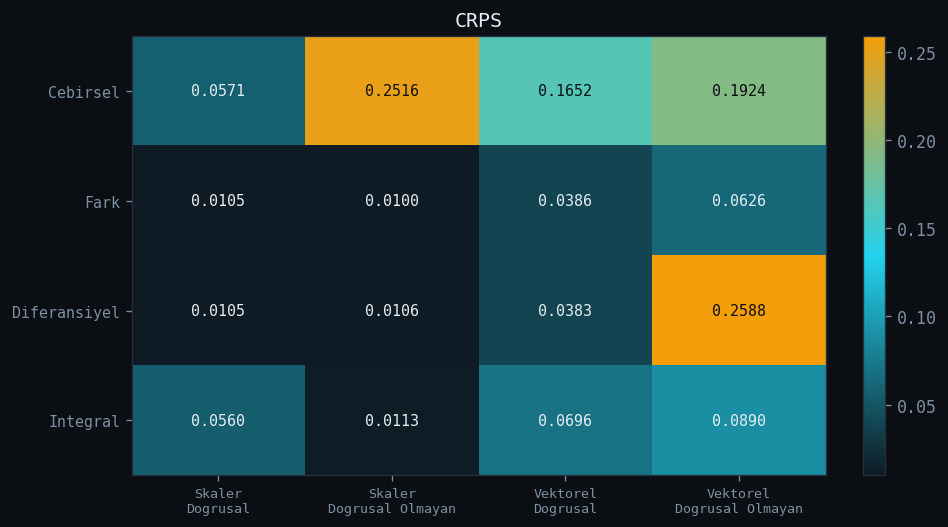

In [23]:
izgara = tablo.pivot_table(index="Tur", columns="Sinif", values="CRPS").loc[turler, siniflar]
deger = izgara.to_numpy()
oran = (deger - deger.min()) / (deger.max() - deger.min())

sekil, eksen = plt.subplots(figsize=(8, 4.5))
resim = eksen.imshow(deger, cmap=harita, aspect="auto")
for i in range(4):
    for j in range(4):
        eksen.text(j, i, f"{deger[i, j]:.4f}", ha="center", va="center",
                   color="#0B0F14" if oran[i, j] > 0.35 else "#E6EDF3", fontsize=9)
eksen.set_xticks(range(4), ["Skaler\nDogrusal", "Skaler\nDogrusal Olmayan", "Vektorel\nDogrusal", "Vektorel\nDogrusal Olmayan"], fontsize=8)
eksen.set_yticks(range(4), turler, fontsize=9)
eksen.set_title("CRPS")
eksen.grid(False)
sekil.colorbar(resim, ax=eksen, fraction=0.03)
plt.tight_layout()
plt.show()

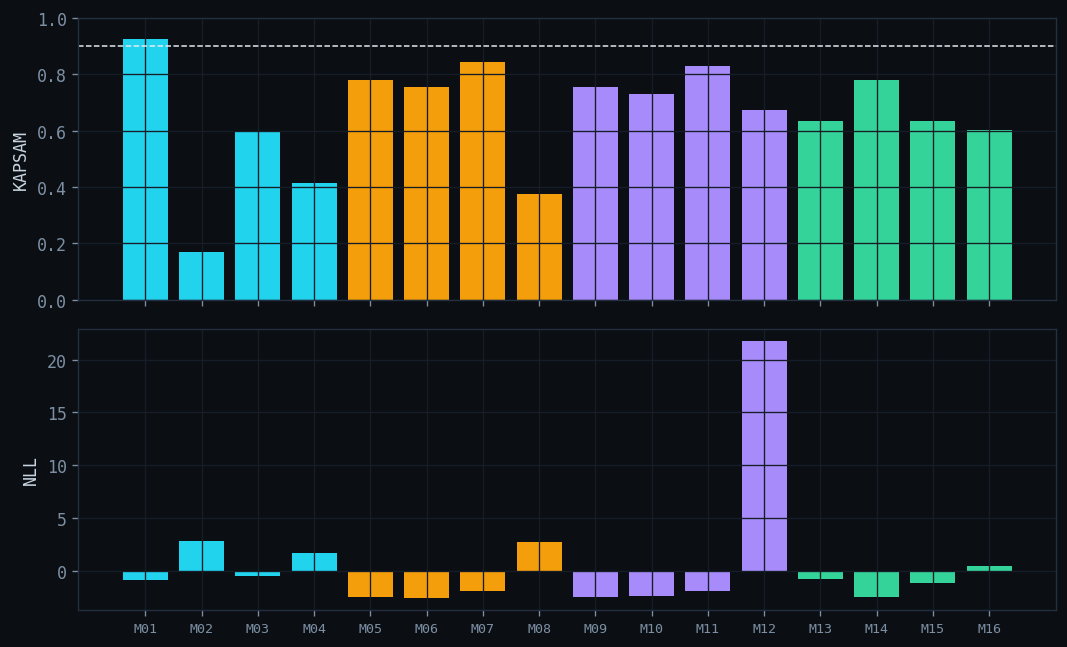

In [24]:
sira = list(sonuclar.keys())
renkler = [paleta[turler.index(sonuclar[k]["Tur"])] for k in sira]

sekil, eksen = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True)
eksen[0].bar(sira, [sonuclar[k]["KAPSAM"] for k in sira], color=renkler)
eksen[0].axhline(0.90, color="#E6EDF3", ls="--", lw=0.9)
eksen[0].set_ylim(0, 1)
eksen[0].set_ylabel("KAPSAM")
eksen[1].bar(sira, [sonuclar[k]["NLL"] for k in sira], color=renkler)
eksen[1].set_ylabel("NLL")
eksen[1].tick_params(axis="x", labelsize=8)
plt.tight_layout()
plt.show()

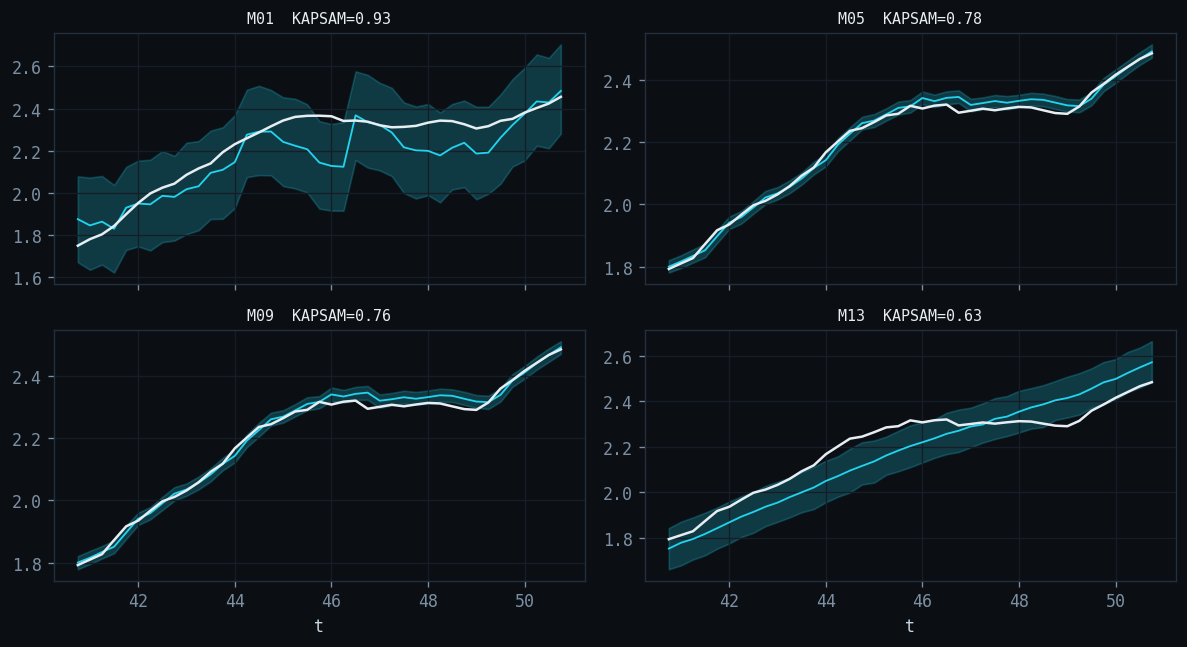

In [25]:
hedefler = {"M01": cikis_skaler[test], "M05": durum_skaler[test], "M09": durum_skaler[test], "M13": durum_skaler[test]}
zaman = t[test]

sekil, eksen = plt.subplots(2, 2, figsize=(10, 5.5), sharex=True)
for e, (kod, gercek) in zip(eksen.ravel(), hedefler.items()):
    alt, orta, ust = araliklar[kod]
    e.fill_between(zaman, alt[:, 0], ust[:, 0], color="#22D3EE", alpha=0.22)
    e.plot(zaman, orta[:, 0], color="#22D3EE", lw=1.1)
    e.plot(zaman, gercek, color="#E6EDF3", lw=1.5)
    e.set_title(f"{kod}  KAPSAM={sonuclar[kod]['KAPSAM']:.2f}", fontsize=9)
eksen[1, 0].set_xlabel("t")
eksen[1, 1].set_xlabel("t")
plt.tight_layout()
plt.show()

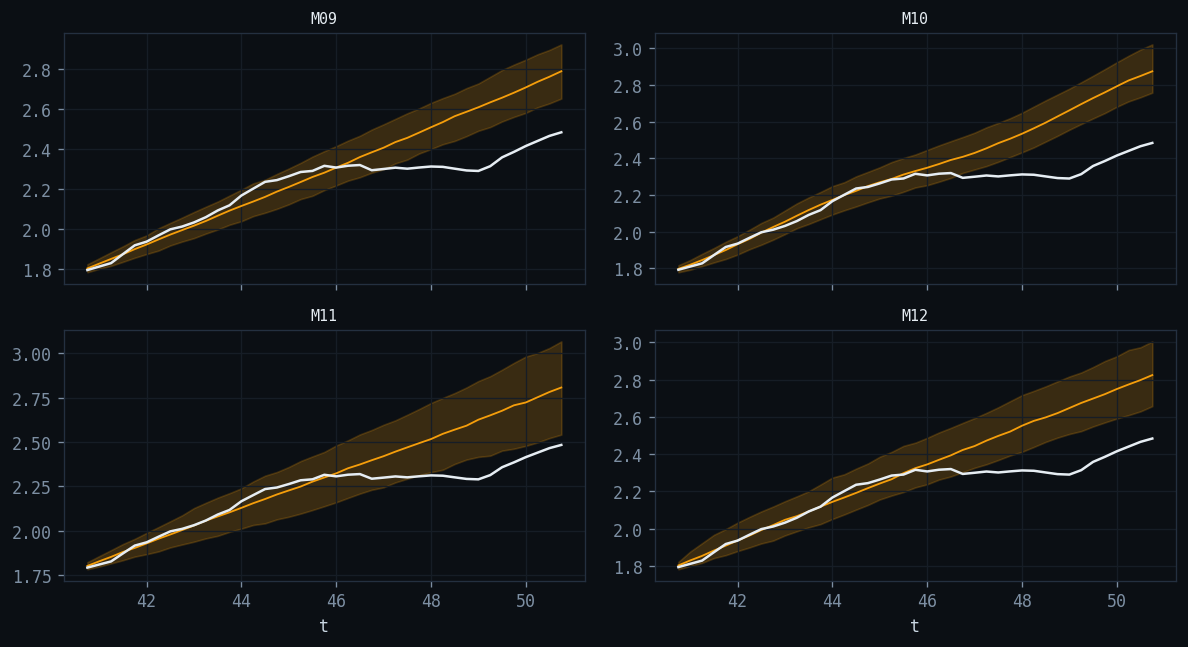

In [26]:
zamanlar = t[kesim - 1:n - 1]
gercekler = {"M09": durum_skaler, "M10": durum_skaler, "M11": durum_vektor[:, 0], "M12": durum_vektor[:, 0]}

sekil, eksen = plt.subplots(2, 2, figsize=(10, 5.5), sharex=True)
for e, kod in zip(eksen.ravel(), ["M09", "M10", "M11", "M12"]):
    alan, S = alanlar[kod]
    bas = np.atleast_1d(durum_skaler[kesim - 1]) if S.shape[0] == 1 else durum_vektor[kesim - 1]
    yol = euler_maruyama(alan, S, bas, zamanlar, adim, 400)[:, 1:, 0]
    alt, orta, ust = np.quantile(yol, [0.05, 0.5, 0.95], axis=0)
    e.fill_between(zamanlar + adim, alt, ust, color="#F59E0B", alpha=0.20)
    e.plot(zamanlar + adim, orta, color="#F59E0B", lw=1.1)
    e.plot(t[test], gercekler[kod][test], color="#E6EDF3", lw=1.5)
    e.set_title(kod, fontsize=9)
eksen[1, 0].set_xlabel("t")
eksen[1, 1].set_xlabel("t")
plt.tight_layout()
plt.show()

In [27]:
tablo.sort_values("CRPS")[["Tur", "Sinif", "RMSE", "CRPS", "NLL", "KAPSAM"]]

,Tur,Sinif,RMSE,CRPS,NLL,KAPSAM
M06,Fark,Skaler Dogrusal Olmayan,0.0175,0.0100,-2.5028,0.7561
M05,Fark,Skaler Dogrusal,0.0182,0.0105,-2.4096,0.7805
M09,Diferansiyel,Skaler Dogrusal,0.0182,0.0105,-2.4096,0.7561
M10,Diferansiyel,Skaler Dogrusal Olmayan,0.0184,0.0106,-2.3207,0.7317
M14,Integral,Skaler Dogrusal Olmayan,0.0189,0.0113,-2.4462,0.7805
M11,Diferansiyel,Vektorel Dogrusal,0.1057,0.0383,-1.8551,0.8293
M07,Fark,Vektorel Dogrusal,0.1057,0.0386,-1.8551,0.8455
M13,Integral,Skaler Dogrusal,0.0870,0.0560,-0.7297,0.6341
M01,Cebirsel,Skaler Dogrusal,0.0992,0.0571,-0.8329,0.9268
M08,Fark,Vektorel Dogrusal Olmayan,0.1281,0.0626,2.7282,0.3740
